In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def read_opensim_file(file_path):
    # OpenSim 文件通常前几行是 header，数据从第 n 行开始
    # 我们通过跳过包含 "endheader" 之前的行来读取
    with open(file_path, 'r') as f:
        lines = f.readlines()
        skip_rows = 0
        for i, line in enumerate(lines):
            if 'endheader' in line:
                skip_rows = i + 1
                break
    
    # 使用 read_csv，分隔符通常为制表符 \t
    return pd.read_csv(file_path, sep='\t', skiprows=skip_rows)

JOINT_DATA_PATH = "/Users/ccg/Downloads/JointMomentExample/subject_scale_walk_JointReaction_ReactionLoads.sto"
data = read_opensim_file(JOINT_DATA_PATH)

GRF_DATA_PATH = "/Users/ccg/Downloads/JointMomentExample/ExpData/grf_walk.mot"
grf_data = read_opensim_file(GRF_DATA_PATH)
grf_data

,time,ground_force_r_vx,ground_force_r_vy,ground_force_r_vz,ground_force_r_px,ground_force_r_py,ground_force_r_pz,ground_torque_r_x,ground_torque_r_y,ground_torque_r_z,ground_force_l_vx,ground_force_l_vy,ground_force_l_vz,ground_force_l_px,ground_force_l_py,ground_force_l_pz,ground_torque_l_x,ground_torque_l_y,ground_torque_l_z
0,0.0000,0.0,0.0,0.0,346.097838,0.0,96.391523,0.0,0.0,0.0,0.0,0.0,0.0,155.462760,0.0,-502.663311,0.0,0.0,0.0
1,0.0005,0.0,0.0,0.0,344.134506,0.0,95.841400,0.0,0.0,0.0,0.0,0.0,0.0,155.190532,0.0,-501.757785,0.0,0.0,0.0
2,0.0010,0.0,0.0,0.0,342.178635,0.0,95.293376,0.0,0.0,0.0,0.0,0.0,0.0,154.918624,0.0,-500.853348,0.0,0.0,0.0
3,0.0015,0.0,0.0,0.0,340.230212,0.0,94.747447,0.0,0.0,0.0,0.0,0.0,0.0,154.647035,0.0,-499.950000,0.0,0.0,0.0
4,0.0020,0.0,0.0,0.0,338.289222,0.0,94.203610,0.0,0.0,0.0,0.0,0.0,0.0,154.375765,0.0,-499.047739,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4773,2.3865,0.0,0.0,0.0,249.483825,0.0,51.071596,0.0,0.0,0.0,0.0,0.0,0.0,133.999738,0.0,-280.485829,0.0,0.0,0.0
4774,2.3870,0.0,0.0,0.0,251.289544,0.0,51.440370,0.0,0.0,0.0,0.0,0.0,0.0,134.264604,0.0,-281.031033,0.0,0.0,0.0
4775,2.3875,0.0,0.0,0.0,253.104054,0.0,51.810918,0.0,0.0,0.0,0.0,0.0,0.0,134.529822,0.0,-281.576943,0.0,0.0,0.0
4776,2.3880,0.0,0.0,0.0,254.927377,0.0,52.183243,0.0,0.0,0.0,0.0,0.0,0.0,134.795391,0.0,-282.123561,0.0,0.0,0.0


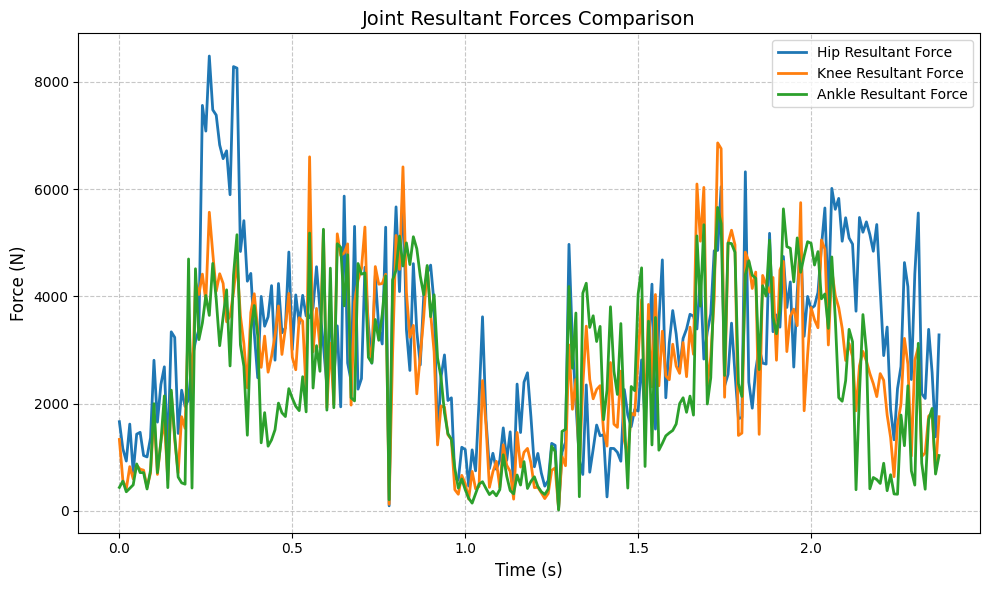

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_joint_forces(file_path):
    # 1. 读取文件，跳过 OpenSim 的 header 部分
    with open(file_path, 'r') as f:
        lines = f.readlines()
        skip_rows = 0
        for i, line in enumerate(lines):
            if 'endheader' in line:
                skip_rows = i + 1
                break
    
    df = pd.read_csv(file_path, sep='\t', skiprows=skip_rows)

    # 2. 定义计算合力的函数
    def calc_resultant(prefix):
        fx = df[f'{prefix}_fx']
        fy = df[f'{prefix}_fy']
        fz = df[f'{prefix}_fz']
        return np.sqrt(fx**2 + fy**2 + fz**2)

    # 3. 计算髋、膝、踝的合力
    # 根据你提供的列名关键词进行匹配
    hip_res = calc_resultant('hip_r_on_femur_r_in_ground')
    knee_res = calc_resultant('walker_knee_r_on_tibia_r_in_ground')
    ankle_res = calc_resultant('ankle_r_on_talus_r_in_ground')

    # 4. 绘图
    plt.figure(figsize=(10, 6))
    plt.plot(df['time'], hip_res, label='Hip Resultant Force', linewidth=2)
    plt.plot(df['time'], knee_res, label='Knee Resultant Force', linewidth=2)
    plt.plot(df['time'], ankle_res, label='Ankle Resultant Force', linewidth=2)

    plt.title('Joint Resultant Forces Comparison', fontsize=14)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Force (N)', fontsize=12) # 或者是 N/BW (如果进行了归一化)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 使用方法：将 'your_results.sto' 替换为你的文件名
plot_joint_forces(JOINT_DATA_PATH)

检测到关节力采样频率约为: 100.00 Hz


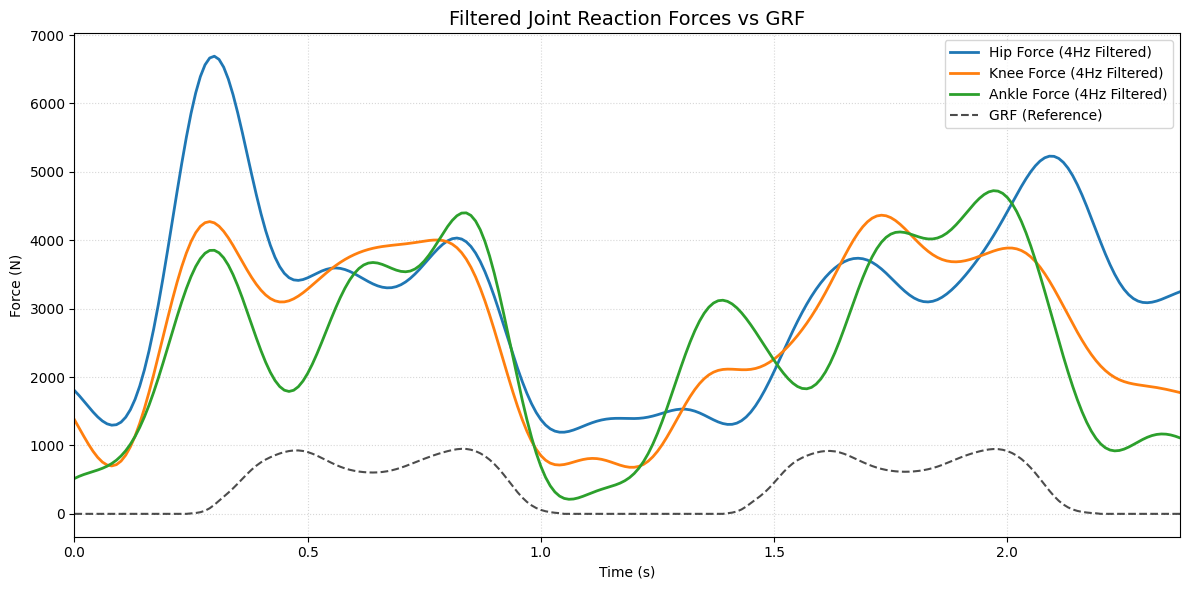

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt

def read_osim_data(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        skip = next(i for i, line in enumerate(lines) if 'endheader' in line) + 1
    return pd.read_csv(file_path, sep='\t', skiprows=skip)

def lowpass_filter(data, cutoff=6, fs=100, order=4):
    """
    低通滤波器
    cutoff: 截止频率 (Hz)，步态分析通常设为 6-10Hz
    fs: 采样频率 (Hz)
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # 使用 filtfilt 进行双向滤波，以消除相位滞后
    return filtfilt(b, a, data)

# 1. 加载数据
df_joint = read_osim_data(JOINT_DATA_PATH) 
df_grf = read_osim_data(GRF_DATA_PATH)

# 2. 确定采样频率 fs (假设关节数据时间轴是均匀的)
time_j = df_joint['time'].values
fs_joint = 1 / np.mean(np.diff(time_j)) 
print(f"检测到关节力采样频率约为: {fs_joint:.2f} Hz")

# 3. 计算各个关节合力
def get_res(df, prefix):
    return np.sqrt(df[f'{prefix}_fx']**2 + df[f'{prefix}_fy']**2 + df[f'{prefix}_fz']**2)

hip_raw = get_res(df_joint, 'hip_r_on_femur_r_in_ground') # 转换为 N
knee_raw = get_res(df_joint, 'walker_knee_r_on_tibia_r_in_ground')  # 转换为 N
ankle_raw = get_res(df_joint, 'ankle_r_on_talus_r_in_ground')  # 转换为 N

# 4. 对关节力进行低通滤波 (核心步骤：消除毛刺)
# 截止频率设为 6Hz 比较稳妥，你可以根据需要调整为 10Hz
cutoff_freq = 4 
hip_f = lowpass_filter(hip_raw, cutoff=cutoff_freq, fs=fs_joint)
knee_f = lowpass_filter(knee_raw, cutoff=cutoff_freq, fs=fs_joint)
ankle_f = lowpass_filter(ankle_raw, cutoff=cutoff_freq, fs=fs_joint)

# 5. 计算地面反力并对齐
grf_raw = np.sqrt(df_grf['ground_force_r_vx']**2 + df_grf['ground_force_r_vy']**2 + df_grf['ground_force_r_vz']**2)
interp_func = interp1d(df_grf['time'], grf_raw, kind='linear', fill_value="extrapolate")
grf_aligned = interp_func(time_j)

# 6. 绘图对比
plt.figure(figsize=(12, 6))

plt.plot(time_j, hip_f, label=f'Hip Force ({cutoff_freq}Hz Filtered)', linewidth=2)
plt.plot(time_j, knee_f, label=f'Knee Force ({cutoff_freq}Hz Filtered)', linewidth=2)
plt.plot(time_j, ankle_f, label=f'Ankle Force ({cutoff_freq}Hz Filtered)', linewidth=2)
plt.plot(time_j, grf_aligned, label='GRF (Reference)', color='black', linestyle='--', alpha=0.7)

plt.title('Filtered Joint Reaction Forces vs GRF', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

# 限制显示范围在有效时间内
plt.xlim(max(df_joint['time'].min(), df_grf['time'].min()), 
         min(df_joint['time'].max(), df_grf['time'].max()))
plt.tight_layout()
plt.show()

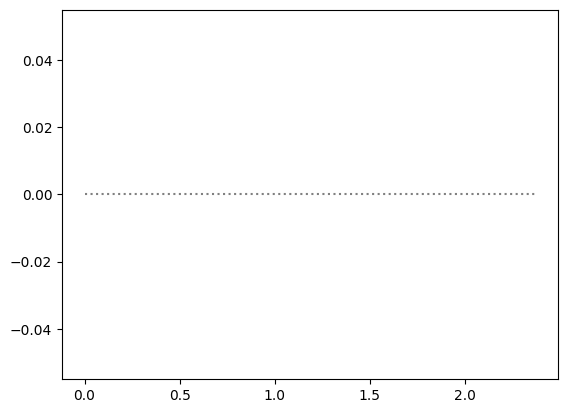

In [26]:

# 监控残余力 (Residual Force)
residual_fz = df_joint['ground_pelvis_on_pelvis_in_ground_fx']
# 对残余力也进行同样的 6Hz 滤波
residual_fz_smooth = lowpass_filter(residual_fz, cutoff=6, fs=fs_joint)

plt.plot(time_j, residual_fz_smooth, label='Residual Force (Quality Metric)', color='gray', linestyle=':')